# Dynamic Parallel Execution with  Map-Reduce using Send in LangGraph


Map-reduce operations are essential for efficient task decomposition and parallel processing.

It has two phases:

(1) `Map` - Break a task into smaller sub-tasks, processing each sub-task in parallel.

(2) `Reduce` - Aggregate the results across all of the completed, parallelized sub-tasks.

We will design a system that will do two things:

(1) `Map` - Create a set of questions about a topic. Then answer them in parallel (using `Send(...)`)

(2) `Reduce` - Compile a comprehensive report based on the QAs on the topic.

![](https://i.imgur.com/SN7KifO.png)


LangGraph's Map-Reduce pattern enables efficient task decomposition and parallel processing, enhancing performance in complex workflows. The Send function plays a pivotal role in this mechanism.

Map-Reduce in LangGraph:
- Task Decomposition: Breaks down a large task into smaller, manageable sub-tasks (planning or complex question decomposition)
- Parallel Processing: Executes sub-tasks concurrently, significantly reducing overall processing time.
- Result Aggregation: Combines outcomes from all sub-tasks to form a comprehensive response.





## Install OpenAI, LangGraph and LangChain dependencies

In [1]:
!pip install langchain==0.3.14
!pip install langchain-openai==0.3.0
!pip install langchain-community==0.3.14
!pip install langgraph==0.2.64

## Enter Open AI API Key

In [2]:
from getpass import getpass

OPENAI_KEY = getpass('Enter Open AI API Key: ')

## Setup Environment Variables

In [3]:
import os

os.environ['OPENAI_API_KEY'] = OPENAI_KEY

## Define Agent State Schema

In [4]:
from typing_extensions import TypedDict
from pydantic import BaseModel
import operator
from typing import Annotated

# Define state
class Questions(BaseModel):
    questions: list[str]

class Answer(BaseModel):
    question: str
    answer: str

class Report(BaseModel):
    report: str

class OverallState(TypedDict):
    topic: str
    questions: list
    answers: Annotated[list, operator.add]
    report: str

## Define Agent Node Functions

Role of the Send Function:
- Dynamic Task Distribution: Utilizes the Send function to dispatch different states to multiple instances of a node, facilitating parallel execution.
- Flexible Workflow Management: Very useful when you do not have a fixed number of static edges to parallelize like in router agent. A simple example would be generating a random number of questions or steps to solve a problem and parallelizing the generation process for each of those questions or steps.

In [5]:
from langgraph.constants import Send
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o", temperature=0)

# Node to generate questions
def generate_questions(state: OverallState):
    # sometimes gpt-4o just generates 5 questions always so feel free to play around with the following prompt
    # or you can also use gpt-4o-mini or other LLMs or just randomly select a subselt of questions from the response
    # just to demonstrate and see how Send works with a variable number of questions
    questions_prompt = """Generate a list of concise sub-questions related to this overall topic: {topic}
                          which would help build a good report.
                          Follow these rules for question generation:
                            - Do not create very long questions.
                            - Number of questions should always be 3 for simple topics (Birds, Animals, AI)
                              and 5 for more complex topics (Outlook for ..., Impact of ...)
                       """
    prompt = questions_prompt.format(topic=state["topic"])
    response = llm.with_structured_output(Questions).invoke(prompt)
    return {"questions": response.questions}

# Node to generate answer to one question
def generate_answer(state: Answer):
    answer_prompt = """Generate the answer about {question}."""
    prompt = answer_prompt.format(question=state["question"])
    response = llm.with_structured_output(Answer).invoke(prompt)
    return {"answers": [{"question": state["question"], "answer": response.answer}]}

# Node to continue to answers
def continue_to_answers(state: OverallState):
    return [Send("generate_answer", {"question": q}) for q in state["questions"]] # does the parallel execution

# Node to compile the report
def compile_report(state: OverallState):
    q_and_a = "\n\n".join(
        [f"Q: {qa['question']}\nA: {qa['answer']}" for qa in state["answers"]]
    )
    report_prompt = """Below are a bunch of questions and answers about topic:
                       {topic}.
                       Generate a detailed report from this about the topic.
                       {q_and_a}"""
    prompt = report_prompt.format(topic=state["topic"], q_and_a=q_and_a)
    response = llm.with_structured_output(Report).invoke(prompt)
    return {"report": response.report}

## Create Agent

In [6]:
from langgraph.graph import StateGraph, START, END

# Compile the graph
graph = StateGraph(OverallState)
graph.add_node("generate_questions", generate_questions)
graph.add_node("generate_answer", generate_answer)
graph.add_node("compile_report", compile_report)

graph.add_edge(START, "generate_questions")
graph.add_conditional_edges("generate_questions",
                            continue_to_answers,
                            ["generate_answer"])
graph.add_edge("generate_answer", "compile_report")
graph.add_edge("compile_report", END)

# Compile the app
agent = graph.compile()

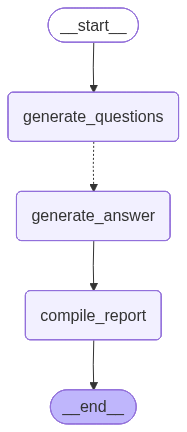

In [7]:
# Display the graph
from IPython.display import display, Image
Image(agent.get_graph().draw_mermaid_png())

## Run and Test the Agent

In [8]:
from IPython.display import display, Markdown

for state in agent.stream({"topic": "Artificial Intelligence"}):
    print(state)
    if 'compile_report' in state:
        display(Markdown(state['compile_report']['report']))

{'generate_questions': {'questions': ['What are the key components of artificial intelligence?', 'How does machine learning differ from traditional programming?', 'What are the ethical considerations in AI development?']}}
{'generate_answer': {'answers': [{'question': 'What are the key components of artificial intelligence?', 'answer': 'Artificial Intelligence (AI) is a broad field that encompasses various technologies and methodologies aimed at creating systems capable of performing tasks that typically require human intelligence. Here are the key components of AI:\n\n1. **Machine Learning (ML):**\n   - **Definition:** A subset of AI that involves the use of algorithms and statistical models to enable computers to improve their performance on a task through experience.\n   - **Key Techniques:** Supervised learning, unsupervised learning, reinforcement learning, and deep learning.\n\n2. **Neural Networks:**\n   - **Definition:** Computational models inspired by the human brain, consist

### Artificial Intelligence: A Comprehensive Overview

Artificial Intelligence (AI) is a transformative technology that has the potential to revolutionize various aspects of human life. This report delves into the key components, differences from traditional programming, and ethical considerations associated with AI development.

#### Key Components of Artificial Intelligence

1. **Machine Learning (ML):**
   - **Definition:** A subset of AI focused on developing algorithms that allow computers to learn from and make predictions based on data.
   - **Techniques:** Includes supervised, unsupervised, reinforcement learning, and deep learning.

2. **Neural Networks:**
   - **Definition:** Inspired by the human brain, these are networks of interconnected nodes that process information.
   - **Types:** Includes feedforward, convolutional, and recurrent neural networks.

3. **Natural Language Processing (NLP):**
   - **Definition:** Enables computers to understand and interact using human language.
   - **Applications:** Language translation, sentiment analysis, and chatbots.

4. **Computer Vision:**
   - **Definition:** Allows computers to interpret visual data from the world.
   - **Applications:** Image and facial recognition, autonomous vehicles.

5. **Robotics:**
   - **Definition:** Involves the creation of robots that can perform tasks autonomously.
   - **Applications:** Used in manufacturing, healthcare, and service industries.

6. **Expert Systems:**
   - **Definition:** Mimic human decision-making in specific domains.
   - **Components:** Include a knowledge base and inference engine.

7. **Fuzzy Logic:**
   - **Definition:** Deals with reasoning that is approximate rather than fixed.
   - **Applications:** Used in control systems and decision-making.

8. **Knowledge Representation and Reasoning:**
   - **Definition:** Techniques to represent information for problem-solving.
   - **Methods:** Ontologies and semantic networks.

9. **Planning and Scheduling:**
   - **Definition:** Creating action sequences to achieve goals.
   - **Applications:** Logistics and autonomous systems.

10. **Reinforcement Learning:**
    - **Definition:** Learning to make decisions by maximizing rewards.
    - **Applications:** Game playing and resource management.

#### Machine Learning vs. Traditional Programming

- **Problem Solving:**
  - Traditional programming involves explicit instructions, while ML learns patterns from data.
- **Data Dependency:**
  - ML is highly data-dependent, whereas traditional programming relies on predefined logic.
- **Flexibility:**
  - ML is adaptable to new data, unlike traditional programming.
- **Outcome Predictability:**
  - ML outcomes can be probabilistic, while traditional programming is deterministic.
- **Use Cases:**
  - ML is ideal for pattern recognition, while traditional programming suits tasks with clear rules.

#### Ethical Considerations in AI Development

1. **Bias and Fairness:**
   - AI systems must avoid perpetuating biases present in training data.

2. **Transparency and Explainability:**
   - Ensuring AI decisions are understandable to build trust.

3. **Privacy and Data Protection:**
   - Safeguarding user data and complying with regulations like GDPR.

4. **Accountability and Responsibility:**
   - Clear guidelines on who is responsible for AI decisions.

5. **Autonomy and Control:**
   - Maintaining human control over AI systems.

6. **Security and Safety:**
   - Designing AI to be secure against attacks and robust against failures.

7. **Impact on Employment:**
   - Addressing job displacement and economic disruption.

8. **Moral and Ethical Decision-Making:**
   - Aligning AI systems with human values.

9. **Environmental Impact:**
   - Minimizing the carbon footprint of AI systems.

10. **Global Inequality:**
    - Ensuring equitable distribution of AI benefits.

### Conclusion

Artificial Intelligence is a multifaceted field with the potential to significantly impact society. Understanding its components, differences from traditional programming, and ethical considerations is crucial for responsible development and deployment. Collaborative efforts are essential to ensure AI technologies are beneficial, fair, and safe for all.

In [9]:
for state in agent.stream({"topic": "Animals"}):
    print(state)
    if 'compile_report' in state:
        display(Markdown(state['compile_report']['report']))

{'generate_questions': {'questions': ['What are the different classifications of animals?', 'How do animals adapt to their environments?', 'What are the key threats to animal biodiversity?']}}
{'generate_answer': {'answers': [{'question': 'How do animals adapt to their environments?', 'answer': 'Animals have developed a wide range of adaptations to survive and thrive in their specific environments. These adaptations can be structural, behavioral, or physiological, and they help animals meet their basic needs such as finding food, avoiding predators, and reproducing. Here are some key ways animals adapt to their environments:\n\n### 1. **Structural Adaptations**\n- **Camouflage:** Many animals have developed colors and patterns that help them blend into their surroundings, making it harder for predators to spot them. For example, the Arctic fox has a white coat in winter to blend in with the snow.\n- **Body Shape and Size:** Animals may evolve specific body shapes that help them move ef

### Detailed Report on Animals

#### Introduction
Animals are a diverse group of living organisms that play crucial roles in ecosystems around the world. They are classified into various categories based on shared characteristics and evolutionary history. This report delves into the classification of animals, their adaptations to environments, and the key threats to their biodiversity.

---

### Classification of Animals

Animals are systematically categorized using the Linnaean system, which organizes them into hierarchical groups. This classification helps scientists understand the evolutionary relationships and characteristics shared among different species.

#### 1. **Kingdom**
- **Animalia**: Encompasses all animals, from the simplest invertebrates to complex vertebrates.

#### 2. **Phylum**
- **Chordata**: Includes animals with a notochord, such as mammals, birds, reptiles, amphibians, and fish.
- **Arthropoda**: Invertebrates with exoskeletons, segmented bodies, and jointed appendages, including insects and crustaceans.
- **Mollusca**: Soft-bodied animals, often with shells, like snails and octopuses.
- **Annelida**: Segmented worms such as earthworms.
- **Cnidaria**: Aquatic animals with stinging cells, like jellyfish.
- **Echinodermata**: Marine animals with radial symmetry, such as starfish.

#### 3. **Class**
- **Mammalia**: Warm-blooded animals with hair and mammary glands.
- **Aves**: Birds, characterized by feathers and beaks.
- **Reptilia**: Cold-blooded, scaly animals like snakes.
- **Amphibia**: Animals living both in water and on land, such as frogs.
- **Pisces**: Fish, aquatic and gill-bearing.
- **Insecta**: The largest class of arthropods, including beetles and ants.

#### 4. **Order, Family, Genus, and Species**
- **Carnivora**: Meat-eating mammals like lions.
- **Primates**: Includes humans and monkeys.
- **Felidae**: Cats, including lions and domestic cats.
- **Homo sapiens**: The species name for humans.

---

### Adaptations of Animals

Animals have evolved a variety of adaptations to survive in their environments. These adaptations can be structural, behavioral, or physiological.

#### 1. **Structural Adaptations**
- **Camouflage**: Enables animals to blend into their surroundings, like the Arctic fox.
- **Body Shape and Size**: Streamlined bodies in fish for efficient swimming.
- **Specialized Appendages**: Giraffes' long necks for reaching high foliage.

#### 2. **Behavioral Adaptations**
- **Migration**: Birds and whales migrate for food and breeding.
- **Hibernation**: Bears hibernate to survive cold winters.
- **Nocturnal Activity**: Owls are active at night to avoid predators.

#### 3. **Physiological Adaptations**
- **Temperature Regulation**: Penguins have insulating fat layers.
- **Metabolic Adjustments**: Some animals slow metabolism during food scarcity.
- **Toxin Resistance**: Newts produce toxins to deter predators.

#### 4. **Reproductive and Ecological Adaptations**
- **Mating Rituals**: Complex behaviors to attract mates.
- **Parental Care**: Elephants invest in raising their young.
- **Niche Specialization**: Birds feeding on different parts of a tree.

---

### Threats to Animal Biodiversity

Animal biodiversity is under threat from various human activities and environmental changes.

#### 1. **Habitat Destruction**
- **Deforestation and Urbanization**: Lead to habitat loss and fragmentation.
- **Agricultural Expansion**: Reduces natural habitats.

#### 2. **Climate Change**
- **Temperature Changes and Extreme Weather**: Affect habitats and species survival.
- **Ocean Acidification**: Impacts marine life, especially coral reefs.

#### 3. **Pollution**
- **Chemical and Plastic Pollution**: Poison wildlife and degrade habitats.

#### 4. **Overexploitation**
- **Overfishing and Hunting**: Deplete populations and disrupt ecosystems.

#### 5. **Invasive Species and Disease**
- **Competition and Predation**: Non-native species outcompete natives.
- **Emerging Diseases**: Spread rapidly among animal populations.

#### 6. **Loss of Genetic Diversity**
- **Inbreeding and Selective Breeding**: Reduce genetic variation and resilience.

---

### Conclusion

The classification, adaptation, and threats to animals highlight the complexity and fragility of animal biodiversity. Addressing these challenges requires global cooperation, sustainable practices, and dedicated conservation efforts to ensure the survival of diverse animal species for future generations.

In [10]:
for state in agent.stream({"topic": "Impact of AI on jobs"}):
    print(state)
    if 'compile_report' in state:
        display(Markdown(state['compile_report']['report']))

{'generate_questions': {'questions': ['What are the primary industries affected by AI automation?', 'How does AI influence job creation versus job displacement?', 'What skills are becoming more valuable due to AI advancements?', 'How are companies adapting their workforce to integrate AI technologies?', 'What are the potential long-term effects of AI on employment rates?']}}
{'generate_answer': {'answers': [{'question': 'What are the primary industries affected by AI automation?', 'answer': 'AI automation is revolutionizing various sectors by enhancing efficiency, reducing costs, and enabling new capabilities. Here are some of the primary industries significantly impacted by AI automation:\n\n1. **Manufacturing:**\n   - **Robotics and Automation:** AI-driven robots are used for assembly lines, quality control, and inventory management.\n   - **Predictive Maintenance:** AI systems predict equipment failures, reducing downtime and maintenance costs.\n\n2. **Healthcare:**\n   - **Diagnost

### Impact of AI on Jobs: A Comprehensive Analysis

Artificial Intelligence (AI) is rapidly transforming industries, reshaping job markets, and redefining the skills required for the future workforce. This report delves into the multifaceted impact of AI on jobs, exploring affected industries, the balance between job creation and displacement, the evolving skill landscape, corporate adaptation strategies, and potential long-term effects on employment rates.

#### Industries Significantly Impacted by AI Automation

AI automation is revolutionizing various sectors by enhancing efficiency, reducing costs, and enabling new capabilities. Key industries experiencing significant AI-driven transformations include:

1. **Manufacturing:**
   - **Robotics and Automation:** AI-driven robots streamline assembly lines, quality control, and inventory management.
   - **Predictive Maintenance:** AI systems predict equipment failures, minimizing downtime and maintenance costs.

2. **Healthcare:**
   - **Diagnostics and Imaging:** AI algorithms assist in interpreting medical images and diagnosing diseases.
   - **Personalized Medicine:** AI helps tailor treatments based on individual patient data.

3. **Finance:**
   - **Algorithmic Trading:** AI systems analyze market data to make rapid trading decisions.
   - **Fraud Detection:** AI models identify unusual patterns and potential fraudulent activities.

4. **Retail:**
   - **Customer Service:** AI chatbots handle customer inquiries and support.
   - **Inventory Management:** AI optimizes stock levels and supply chain logistics.

5. **Transportation and Logistics:**
   - **Autonomous Vehicles:** AI powers self-driving cars and drones for deliveries.
   - **Route Optimization:** AI systems improve delivery routes and reduce fuel consumption.

6. **Agriculture:**
   - **Precision Farming:** AI analyzes data from sensors and drones to optimize crop yields.
   - **Automated Harvesting:** AI-driven machinery assists in planting and harvesting crops.

7. **Energy:**
   - **Smart Grids:** AI optimizes energy distribution and consumption.
   - **Predictive Analytics:** AI forecasts energy demand and supply fluctuations.

8. **Telecommunications:**
   - **Network Optimization:** AI enhances network performance and reliability.
   - **Customer Experience:** AI personalizes services and improves customer interactions.

9. **Education:**
   - **Personalized Learning:** AI tailors educational content to individual learning styles.
   - **Administrative Automation:** AI streamlines administrative tasks and data management.

10. **Entertainment and Media:**
    - **Content Creation:** AI generates music, art, and written content.
    - **Recommendation Systems:** AI suggests personalized content to users.

#### AI's Influence on Job Creation vs. Job Displacement

The influence of AI on job creation and displacement is a complex issue, sparking debate among economists, technologists, and policymakers. Here's a breakdown:

- **Job Displacement:**
  - **Automation of Routine Tasks:** AI excels at automating repetitive tasks, leading to job displacement in sectors like manufacturing and customer service.
  - **Efficiency and Cost Reduction:** Businesses may adopt AI to increase efficiency, potentially leading to workforce reductions.
  - **Skill Mismatch:** A mismatch between existing skills and those required for new roles may lead to temporary unemployment.

- **Job Creation:**
  - **New Industries and Roles:** AI is driving the creation of new industries, such as AI development and data science.
  - **Augmentation of Human Roles:** AI can augment human capabilities, allowing workers to focus on complex tasks.
  - **Increased Demand for Tech Skills:** The rise of AI has increased the demand for tech-savvy professionals.
  - **Economic Growth and Innovation:** AI fosters innovation and creates new business opportunities.

#### Skills Becoming More Valuable Due to AI Advancements

As AI continues to evolve, certain skills are becoming increasingly valuable:

1. **Data Literacy:** Understanding data collection, analysis, and interpretation is crucial.
2. **Programming and Coding:** Skills in languages like Python and R are essential for AI development.
3. **Machine Learning and AI Development:** Expertise in designing and deploying machine learning models is critical.
4. **Critical Thinking and Problem Solving:** Tackling complex problems and devising innovative solutions are key.
5. **Ethical and Responsible AI Use:** Understanding the ethical implications of AI is vital.
6. **Interdisciplinary Knowledge:** Combining knowledge from various fields leads to holistic AI solutions.
7. **Communication and Collaboration:** Communicating technical concepts and collaborating across teams is essential.
8. **Adaptability and Continuous Learning:** Continuously updating skills and adapting to new technologies is necessary.
9. **User Experience (UX) Design:** Designing intuitive interfaces for AI applications ensures accessibility.
10. **Project Management:** Managing AI projects requires understanding both technical and business aspects.

#### Corporate Adaptation Strategies for AI Integration

Companies are taking strategic steps to integrate AI into their operations:

1. **Upskilling and Reskilling Programs:** Investing in training programs to equip employees with AI-relevant skills.
2. **Hiring AI Specialists:** Actively recruiting data scientists and AI specialists to lead AI integration efforts.
3. **Redefining Roles and Responsibilities:** Focusing on strategic, creative, and interpersonal skills.
4. **Fostering a Culture of Innovation:** Encouraging experimentation with AI tools and solutions.
5. **Implementing AI Tools for Workforce Management:** Utilizing AI for recruitment and performance management.
6. **Ensuring Ethical AI Use:** Developing frameworks to ensure responsible AI use.
7. **Collaborating with External Partners:** Partnering with tech firms to access AI solutions and expertise.

#### Potential Long-term Effects of AI on Employment Rates

The integration of AI into various sectors has sparked debate about its potential long-term effects on employment rates:

1. **Job Displacement:**
   - **Automation of Routine Tasks:** AI can automate repetitive tasks, leading to job displacement.
   - **Reduction in Demand for Certain Skills:** The demand for certain skills may decrease.

2. **Job Creation:**
   - **New Industries and Roles:** AI can lead to the creation of new industries and job roles.
   - **Increased Demand for Tech Skills:** There will be a growing need for AI-skilled professionals.

3. **Job Transformation:**
   - **Augmentation of Human Roles:** AI can augment human capabilities, transforming existing roles.
   - **Reskilling and Upskilling:** Workers may need to acquire new skills to adapt to AI-driven changes.

4. **Economic and Social Impacts:**
   - **Wage Polarization:** A widening wage gap between high-skilled and low-skilled workers.
   - **Regional Disparities:** Areas reliant on industries vulnerable to automation may face higher unemployment rates.

5. **Policy and Regulatory Responses:**
   - **Government Intervention:** Policies such as universal basic income and retraining programs may be necessary.
   - **Ethical and Legal Considerations:** Ensuring fair labor practices and addressing ethical concerns.

6. **Long-term Economic Growth:**
   - **Productivity Gains:** AI can lead to significant productivity improvements.
   - **Innovation and Competitiveness:** Effective AI integration can foster innovation and economic expansion.

### Conclusion

AI is reshaping industries, driving innovation, and creating new opportunities. However, it also poses challenges such as job displacement and ethical considerations. The key to harnessing AI's potential lies in managing the transition effectively through education, policy, and innovation. By proactively addressing these challenges, societies can ensure a balanced and inclusive technological advancement that benefits all.